#  Классификация текстов с использованием эмбеддингов слов.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://rusvectores.org/
* https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html
* https://github.com/natasha/navec
* https://pytorch.org/docs/stable/generated/torch.nn.Embedding.html
* https://torchmetrics.readthedocs.io/en/stable/
* https://github.com/natasha/navec

## Задачи для совместного разбора

1\. Реализуйте модель для классификации текстов с использованием слоя `nn.Embedding`. Заморозьте веса слоя эмбеддингов.

In [2]:
import torch as th

X = th.randint(0, 1000, size=(16, 20)).long()
y = th.full(size=(16, ), fill_value=0.5).bernoulli().long()

In [3]:
import torch.nn as nn

class Net(nn.Module):
  def __init__(
      self,
      num_embeddings: int,
      embedding_dim: int,
      num_classes: int) -> None:
    super().__init__()
    self.embedding = nn.Embedding(
        num_embeddings,
        embedding_dim
    )
    self.fc = nn.Linear(embedding_dim, num_classes)

  def forward(self, X):
     e = self.embedding(X) # b x s x e
     e_s = e.mean(dim=1)
     out = self.fc(e_s)
     return out

## Задачи для самостоятельного решения

In [30]:
import pandas as pd
import nltk
import gensim
import pymorphy3
nltk.download("stopwords")
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer, word_tokenize
from nltk.util import ngrams
import torch as th
from gensim.models import Word2Vec
import random
from functools import reduce
from torch.utils.data import Dataset
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
import itertools
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from functools import reduce
from nltk.tokenize import RegexpTokenizer
import pandas as pd
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import BpeTrainer
from tokenizers.normalizers import Lowercase, Strip, Replace, Sequence as NormalizerSequence
from tokenizers import Regex
from tokenizers.processors import TemplateProcessing
from itertools import permutations
from tokenizers import Tokenizer
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.trainers import WordLevelTrainer

[nltk_data] Downloading package stopwords to C:\Users\Rog
[nltk_data]     G16\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<p class="task" id="1"></p>

1\. Считайте файл `lenta_news.csv` и разбейте на обучающую и тестовую выборку. Выполните предобработку текста и создайте Tokenizer на основе обучающей выборки (токен - слово). Выведите на экран количество токенов в полученном словаре. Обратите внимание, что построение словаря токенов должно производиться исключительно на основе обучающей выборки.

- [ ] Проверено на семинаре

In [5]:
df = pd.read_csv("data/lenta_news.csv")

all_texts = df['text'].values
all_labels = df['topic'].values 


train_texts, test_texts, train_labels, test_labels = train_test_split(
    all_texts, all_labels, test_size=0.2, stratify=all_labels
)

In [6]:
tokenizer = RegexpTokenizer(r"[A-zА-я]+")


morph = pymorphy3.MorphAnalyzer()

ru_stops = set(stopwords.words('russian'))
en_stops = set(stopwords.words('english'))

            
text2index = {}
index2text = {}
for idx, text in enumerate(train_texts):
    
    sirye = tokenizer.tokenize(text)
    
    tokens = []
    for word in sirye :
        word = word.lower()
        if word not in ru_stops and word not in en_stops:
            tokens.append(morph.parse(word)[0].normal_form)
    text2index[text] = idx
    index2text[idx] = tokens

In [7]:
tokenizer_ws = Tokenizer(WordLevel(unk_token="[UNK]"))
tokenizer_ws.pre_tokenizer = Whitespace()
trainer_ws = WordLevelTrainer(special_tokens=["[PAD]", "[UNK]", "[SOS]", "[EOS]"], vocab_size=1000000)

tokenizer_ws.train_from_iterator(index2text.values(), trainer=trainer_ws)
# tokenizer_ws.enable_padding(
#     pad_id=tokenizer_ws.token_to_id("[PAD]"),
#     pad_token="[PAD]",
#     length=400
# )

In [8]:
tokenizer_ws.decode(range(10))

'год который свой компания россия сообщать'

In [9]:
tokenizer_ws.get_vocab()['[PAD]']

0

In [10]:
len(tokenizer_ws.get_vocab())

84117

In [31]:
np.mean(list(map(lambda x: len(x), index2text.values())))

np.float64(127.30502635836943)

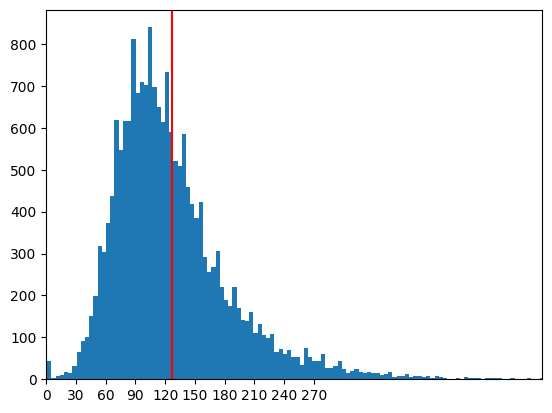

In [33]:
plt.hist(list(map(lambda x: len(x), index2text.values())), bins=200)
plt.xticks([i*30 for i in range(10)])
plt.xlim((0,500))
plt.axvline(127, c='r')
plt.show()

<p class="task" id="2"></p>


2\. Создайте класс `NewsDataset`. Реализуйте метод `__getitem__` таким образом, чтобы он возвращал набор индексов токенов для текста новости $i$ и метку класса для этой новости. Сделайте длины наборов индексов одинаковой фиксированной длины (подходящее значение определите сами). Используйте индекс 0 для паддинга. Закодируйте целыми числами категории новостей. Создайте два объекта класса `NewsDataset` (для обучающей и тестовой выборки).

Выведите на экран результат выполнения `train_dataset[0]`

- [ ] Проверено на семинаре

In [25]:
class PadTruncate:
    def __init__(self, n, pad_idx=0):
        self.n = n
        self.pad_idx = pad_idx
    
    def __call__(self, text):
        res = []
        if len(text)>=self.n:
            res.append(text[:self.n])
        else:
            res.append(text + [0]*(self.n - len(text)))
                
        return res


class NewsDataset(Dataset):
    def __init__(self, 
                 texts: list[str], 
                 labels: list[str], 
                 tokenizer, 
                 max_length: int = 40,
                 label2id: dict[str, int] = None):
        """
        Args:
            texts: Список текстов новостей.
            labels: Список меток для каждой новости.
            tokenizer: Обученный токенайзер.
            max_length: Фиксированная длина последовательности.
            label2id: Словарь маппинга {'category': int}. Если None, строится автоматически.
        """
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        
        self.pad_trun = PadTruncate(self.max_length)
        
        if label2id is None:
            unique_labels = sorted(list(set(labels)))
            self.label2id = {label: i for i, label in enumerate(unique_labels)}
        else:
            self.label2id = label2id
            
    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int):
        text = str(self.texts[idx])
        
        some_tokenizer = RegexpTokenizer(r"[A-zА-я]+")
            
        sirye = some_tokenizer.tokenize(text)
        
        tokens = []
        for word in sirye:
            word = word.lower()
            if word not in ru_stops and word not in en_stops:
                tokens.append(morph.parse(word)[0].normal_form)
            
        label_str = self.labels[idx]
        encoding = self.tokenizer.encode(tokens, is_pretokenized=True)
            
        ids = encoding.ids
        ids = self.pad_trun(ids)
        label_id = self.label2id[label_str]
        return torch.tensor(ids), torch.tensor(label_id)

In [34]:
train_dataset = NewsDataset(
    texts=train_texts,
    labels=train_labels,
    tokenizer=tokenizer_ws,
    max_length=127
)

test_dataset = NewsDataset(
    texts=test_texts,
    labels=test_labels,
    tokenizer=tokenizer_ws,
    max_length=127,
    label2id=train_dataset.label2id
)

print(f"Пример: {train_dataset[1]}\n")

print(f"Классы: {train_dataset.label2id}")

Пример: (tensor([[  126,  1853,    91,   481,   724,   280,    61,  1817,   181, 17731,
         18792, 22301, 35671,     9,    25,   286,   458,   426,  1937,  3976,
          5026,    91,    15,  4968,  2907,    36,   162,  1749,  5177,   259,
           107,    10,  1720,   236,   116,    22,   152, 18792,   212,     5,
          1346,  3007,   209,   199,   107,  7812,    19,  3819,  1268,  5511,
           218,   552,  2526,   380,    19, 14639, 35671,     5,  3007,  1801,
         18792,   633,   327,   267,  3120,  1817,    55,   150, 32706,   199,
          1255,   674,  1928,    55,  1135,   218,    10,    40,  1975,   199,
          1620,  2902,  2812,  3426,  1898,   380,  1268,    19,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,

<p class="task" id="3"></p>

3\. Реализуйте модель для классификации текстов. Архитектура:
- слой `nn.Embedding` (матрица эмбеддингов инициализируется случайным образом; обязательно укажите padding_idx)
- агрегация : для получения эмбеддинга для новости на основе эмбеддингов слов воспользуйтесь любой функцией агрегации, сохраняющей размерности векторов (сумма, усреднение и т.д.). Если используете среднее, помните, что паддинги (нули) занижают среднее значение - это нужно учесть
- классификатор:  состоит из некоторого количества полносвязных слоев (рекомендуется добавить dropout для регуляризации)

Решите задачу классификации новостей. Постройте график изменения значения функции потерь на обучающем множестве в зависимости от номера эпохи, графики изменения метрики f1 на обучающем и тестовом множестве в зависимости от эпохи. Выведите на экран отчет по классификации на обучающем и тестовом множестве.

- [ ] Проверено на семинаре

<p class="task" id="4"></p>

4\. Повторите решение задачи 3, создав слой `nn.Embedding` на основе предобученных векторов для слов русского языка и заморозив веса данного слоя. Для поиска векторов можете воспользоваться любым известным вам ресурсом. Сравните качество полученного решения и решения из предыдущей задачи, а также время, затраченное на обучения моделей.  

- [ ] Проверено на семинаре

<p class="task" id="5"></p>

5\. Повторите решение задачи 3, не замораживая веса слоя эмбеддингов. Сравните качество полученного решения и решений из предыдущих задач, а также время, затраченное на обучения моделей.  

- [ ] Проверено на семинаре

<p class="task" id="6"></p>

6\. Постройте матрицу ошибок для лучшей модели на тестовой выборке. Прокомментируйте, какие классы модель путает чаще всего.

Визуализируйте эмбеддинги новостей из тестовой выборки в двумерном пространстве. Для проекции точек в двумерное пространство воспользуйтесь алгоритмом t-SNE. Раскрасьте точки в цвет, соответствующий классу новости. Прокомментируйте, видно ли разделение на кластеры по классу новостей.

- [ ] Проверено на семинаре